In [1]:
# papermill parameters
DATA_DIR = "data/companies"
INDEX_PATH = "data/companies_index.json"

In [2]:
import json
import glob
import warnings
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

# Prague AI Catalog — Exploratory Data Analysis
375 entities: companies, research groups, initiatives.

## 1. Load data

In [3]:
records = []
for path in sorted(glob.glob(f"{DATA_DIR}/*.json")):
    with open(path) as f:
        records.append(json.load(f))

with open(INDEX_PATH) as f:
    index = {c["id"]: c for c in json.load(f)}

print(f"Loaded {len(records)} company profiles")

Loaded 373 company profiles


In [4]:
def g(d, *keys, default=None):
    """Safe nested get."""
    for k in keys:
        if not isinstance(d, dict):
            return default
        d = d.get(k, default)
        if d is None:
            return default
    return d


rows = []
for r in records:
    rows.append(
        {
            "id": r.get("id"),
            "name": r.get("name"),
            "category": r.get("category"),
            # classification
            "business_type": g(r, "classification", "business_type"),
            "company_type": g(r, "classification", "company_type"),
            "is_ai_native": g(r, "classification", "is_ai_native"),
            "ai_focus": g(r, "classification", "ai_focus", default=[]),
            "industries_served": g(
                r, "classification", "industries_served", default=[]
            ),
            # history
            "founded_year": g(r, "history", "founded_year"),
            # size
            "employees_range": g(r, "size", "employees_range"),
            # financials
            "funding_total_usd": g(r, "financials", "funding_total_usd"),
            "funding_rounds": g(r, "financials", "funding_rounds", default=[]),
            "investors": g(r, "financials", "investors", default=[]),
            "business_model": g(r, "financials", "business_model"),
            "publicly_traded": g(r, "financials", "publicly_traded"),
            # careers
            "hiring_signals": g(r, "careers", "hiring_signals"),
            "open_roles_count": g(r, "careers", "open_roles_count"),
            "open_roles": g(r, "careers", "open_roles", default=[]),
            "tech_stack": g(r, "careers", "tech_stack", default=[]),
            # glassdoor
            "glassdoor_rating": g(r, "glassdoor", "rating"),
            "glassdoor_reviews": g(r, "glassdoor", "review_count"),
            # risk
            "agi_displacement": g(r, "risk_assessment", "agi_displacement"),
            "market_risk": g(r, "risk_assessment", "market_risk"),
            "funding_risk": g(r, "risk_assessment", "funding_risk"),
            "overall_risk": g(r, "risk_assessment", "overall_risk"),
            # recognition
            "awards": g(r, "recognition", "awards", default=[]),
            "notable_clients": g(r, "recognition", "notable_clients", default=[]),
            "customer_count": g(r, "recognition", "customer_count"),
            # metadata
            "data_quality": g(r, "metadata", "data_quality"),
        }
    )

df = pd.DataFrame(rows)

# Derived columns
RISK_ORDER = ["low", "medium", "high"]
EMP_ORDER = ["1-10", "11-50", "51-200", "201-500", "501-1000", "1001-5000", "5000+"]

df["is_funded"] = df["funding_total_usd"].notna() | df["funding_rounds"].apply(
    lambda x: len(x) > 0
)
df["is_hiring"] = df["hiring_signals"] == "actively_hiring"
df["n_open_roles"] = df["open_roles"].apply(len)
df["n_ai_focus"] = df["ai_focus"].apply(len)
df["n_investors"] = df["investors"].apply(len)
df["n_awards"] = df["awards"].apply(len)
df["funding_M"] = df["funding_total_usd"].apply(lambda x: x / 1e6 if x else None)
df["emp_ord"] = pd.Categorical(
    df["employees_range"], categories=EMP_ORDER, ordered=True
)
df["overall_risk_ord"] = pd.Categorical(
    df["overall_risk"], categories=RISK_ORDER, ordered=True
)

companies = df[df["category"] == "company"].copy()

print(
    f"Total: {len(df)} | Companies: {len(companies)} | Research groups: {len(df[df['category'] != 'company'])}"
)
df[
    [
        "id",
        "name",
        "category",
        "company_type",
        "is_ai_native",
        "employees_range",
        "overall_risk",
        "hiring_signals",
        "is_funded",
    ]
].head(10)

Total: 373 | Companies: 323 | Research groups: 50


,id,name,category,company_type,is_ai_native,employees_range,overall_risk,hiring_signals,is_funded
0,2n-telekomunikace,2N TELEKOMUNIKACE,company,acquired,False,501-1000,low,few_roles,False
1,2t-consulting,2T Consulting,company,startup,False,1-10,high,unknown,False
2,accenture,Accenture,company,enterprise,False,5000+,low,actively_hiring,False
3,acrea,ACREA,company,enterprise,False,11-50,medium,unknown,False
4,actum,Actum Digital,company,enterprise,False,501-1000,low,few_roles,False
5,adaptive-data-mgmt,Adaptive Data Management Research Group,research_group,research_lab,False,1-10,not_applicable,unknown,False
6,adastra,Adastra,company,enterprise,False,501-1000,low,unknown,False
7,addai-life,AddAI.Life,company,startup,True,1-10,high,unknown,False
8,advokatni-asoc-ai,Advokátní asociace pro AI,initiative,nonprofit,False,1-10,not_applicable,unknown,False
9,agentfly-tech,AgentFly Technologies,company,startup,True,11-50,medium,unknown,False


## 2. Ecosystem overview

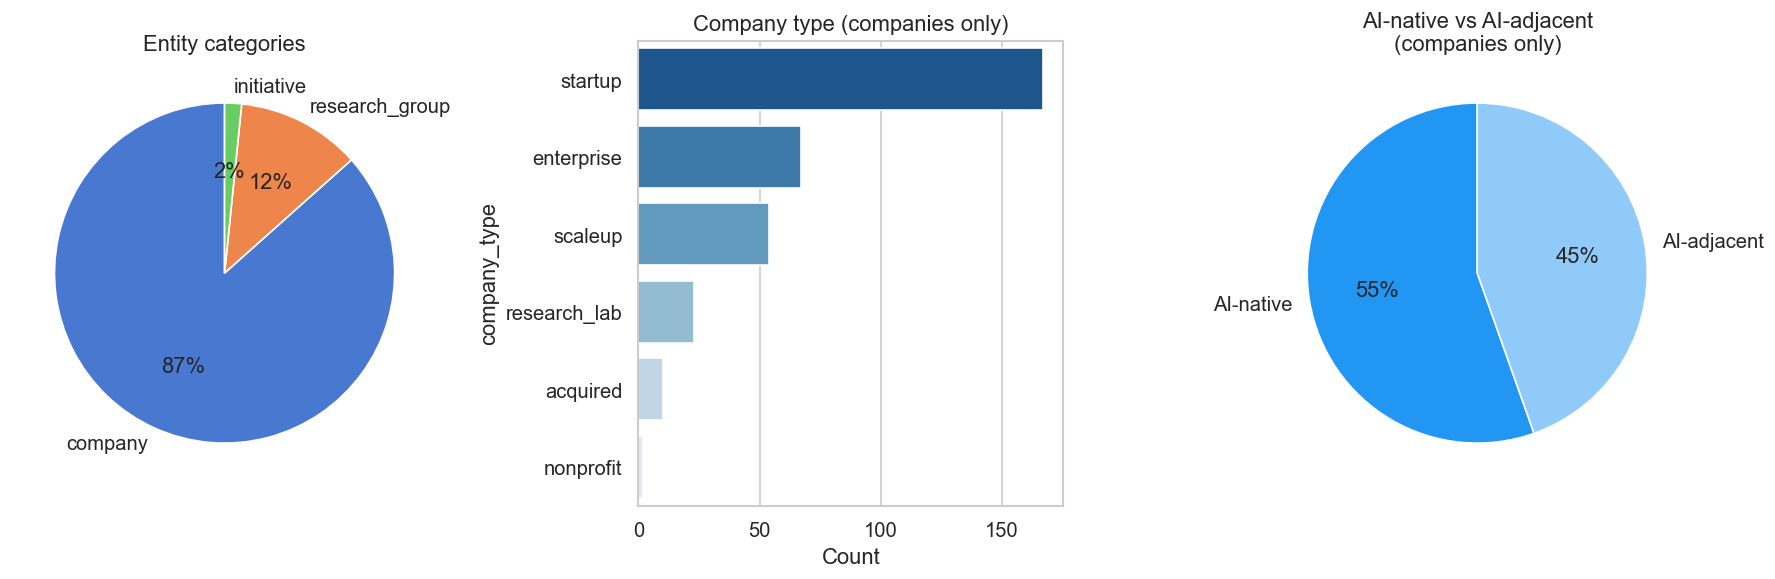

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Category breakdown
cat_counts = df["category"].value_counts()
axes[0].pie(cat_counts, labels=cat_counts.index, autopct="%1.0f%%", startangle=90)
axes[0].set_title("Entity categories")

# Company type (companies only)
ct = companies["company_type"].value_counts()
sns.barplot(x=ct.values, y=ct.index, ax=axes[1], palette="Blues_r")
axes[1].set_title("Company type (companies only)")
axes[1].set_xlabel("Count")

# AI-native split
ai_native = companies["is_ai_native"].value_counts()
axes[2].pie(
    ai_native,
    labels=["AI-native", "AI-adjacent"],
    autopct="%1.0f%%",
    colors=["#2196F3", "#90CAF9"],
    startangle=90,
)
axes[2].set_title("AI-native vs AI-adjacent\n(companies only)")

plt.tight_layout()
plt.show()

## 3. Founding year — ecosystem growth curve

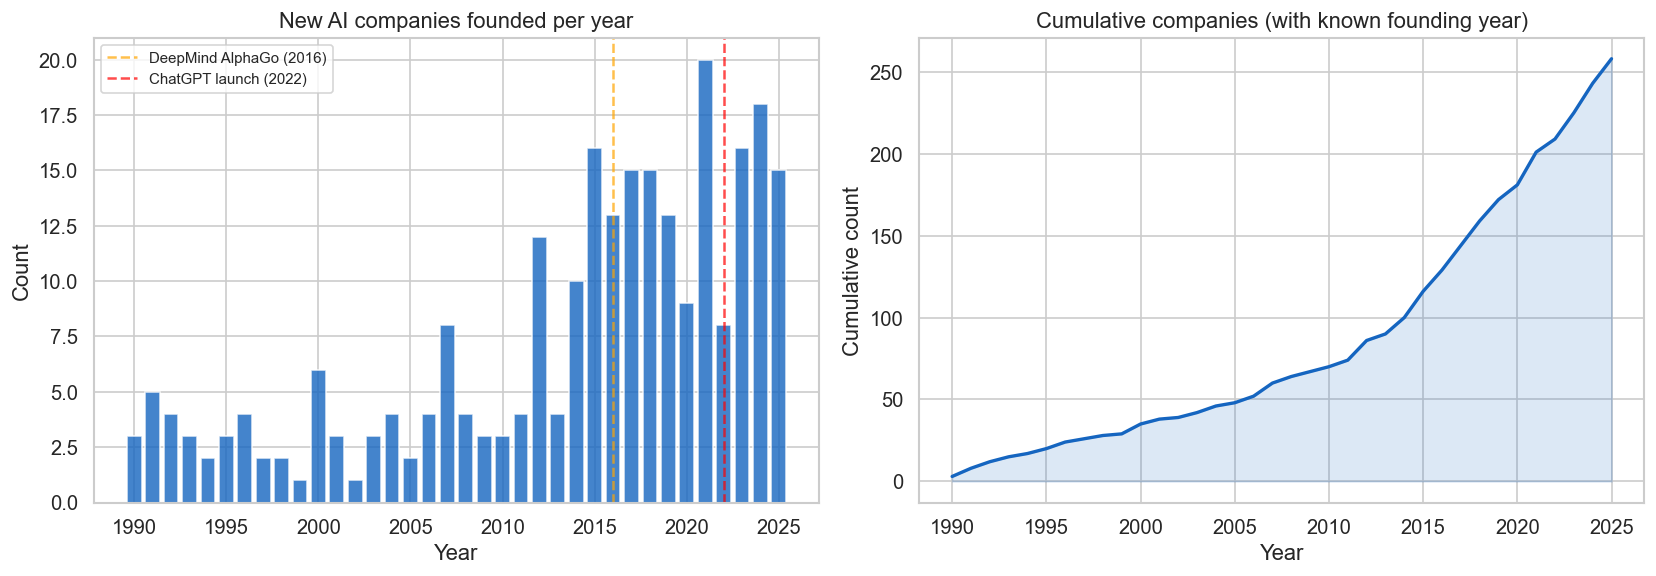

Founded before 2020: 172 | 2020+: 86 (33% of known)


In [6]:
founded = companies[
    companies["founded_year"].notna() & (companies["founded_year"] >= 1990)
].copy()
founded["founded_year"] = founded["founded_year"].astype(int)

year_counts = founded["founded_year"].value_counts().sort_index()
year_cumsum = year_counts.cumsum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(year_counts.index, year_counts.values, color="#1565C0", alpha=0.8)
ax1.set_title("New AI companies founded per year")
ax1.set_xlabel("Year")
ax1.set_ylabel("Count")
ax1.axvline(
    2016, color="orange", linestyle="--", alpha=0.7, label="DeepMind AlphaGo (2016)"
)
ax1.axvline(2022, color="red", linestyle="--", alpha=0.7, label="ChatGPT launch (2022)")
ax1.legend(fontsize=9)

ax2.plot(year_cumsum.index, year_cumsum.values, color="#1565C0", linewidth=2)
ax2.fill_between(year_cumsum.index, year_cumsum.values, alpha=0.15, color="#1565C0")
ax2.set_title("Cumulative companies (with known founding year)")
ax2.set_xlabel("Year")
ax2.set_ylabel("Cumulative count")

plt.tight_layout()
plt.show()

# Post-ChatGPT surge
pre = founded[founded["founded_year"] < 2020]["founded_year"].count()
post = founded[founded["founded_year"] >= 2020]["founded_year"].count()
print(
    f"Founded before 2020: {pre} | 2020+: {post} ({100 * post / (pre + post):.0f}% of known)"
)

## 4. AI focus areas

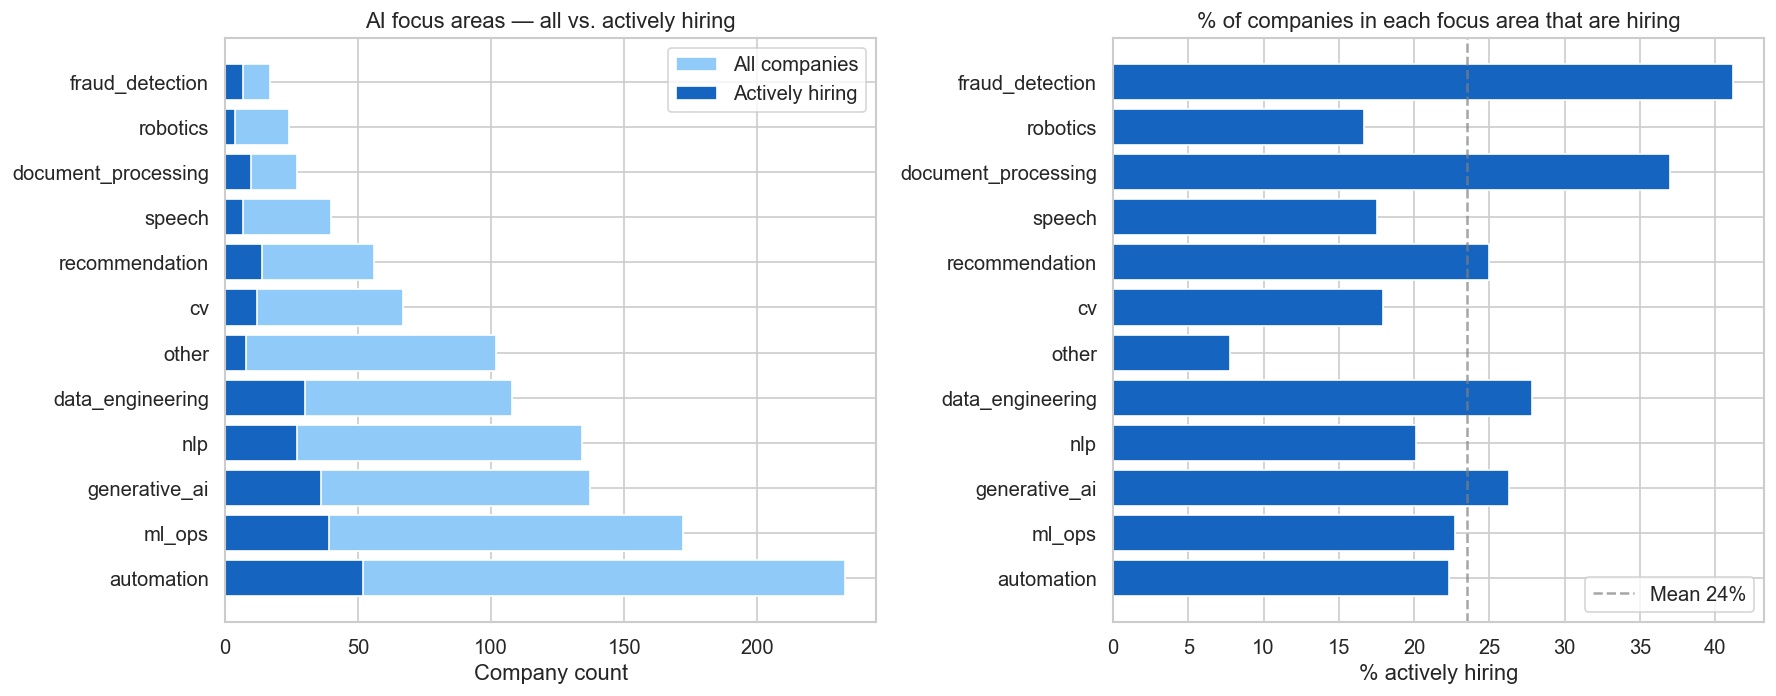

              focus  count  hiring_count  hiring_pct
         automation    233            52        22.3
             ml_ops    172            39        22.7
      generative_ai    137            36        26.3
                nlp    134            27        20.1
   data_engineering    108            30        27.8
              other    102             8         7.8
                 cv     67            12        17.9
     recommendation     56            14        25.0
             speech     40             7        17.5
document_processing     27            10        37.0
           robotics     24             4        16.7
    fraud_detection     17             7        41.2


In [7]:
focus_counter = Counter(tag for tags in df["ai_focus"] for tag in tags)
focus_df = pd.DataFrame(focus_counter.most_common(), columns=["focus", "count"])

# Split by hiring
focus_hiring = Counter(
    tag for _, row in df[df["is_hiring"]].iterrows() for tag in row["ai_focus"]
)
focus_df["hiring_count"] = focus_df["focus"].map(focus_hiring).fillna(0).astype(int)
focus_df["hiring_pct"] = (focus_df["hiring_count"] / focus_df["count"] * 100).round(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

colors = ["#1565C0" if h > 40 else "#90CAF9" for h in focus_df["hiring_pct"]]
bars = ax1.barh(
    focus_df["focus"], focus_df["count"], color="#90CAF9", label="All companies"
)
ax1.barh(
    focus_df["focus"],
    focus_df["hiring_count"],
    color="#1565C0",
    label="Actively hiring",
)
ax1.set_title("AI focus areas — all vs. actively hiring")
ax1.set_xlabel("Company count")
ax1.legend()

ax2.barh(
    focus_df["focus"],
    focus_df["hiring_pct"],
    color=["#C62828" if p > 50 else "#1565C0" for p in focus_df["hiring_pct"]],
)
ax2.axvline(
    focus_df["hiring_pct"].mean(),
    color="gray",
    linestyle="--",
    alpha=0.7,
    label=f"Mean {focus_df['hiring_pct'].mean():.0f}%",
)
ax2.set_title("% of companies in each focus area that are hiring")
ax2.set_xlabel("% actively hiring")
ax2.legend()

plt.tight_layout()
plt.show()
print(focus_df.to_string(index=False))

## 5. Industry landscape

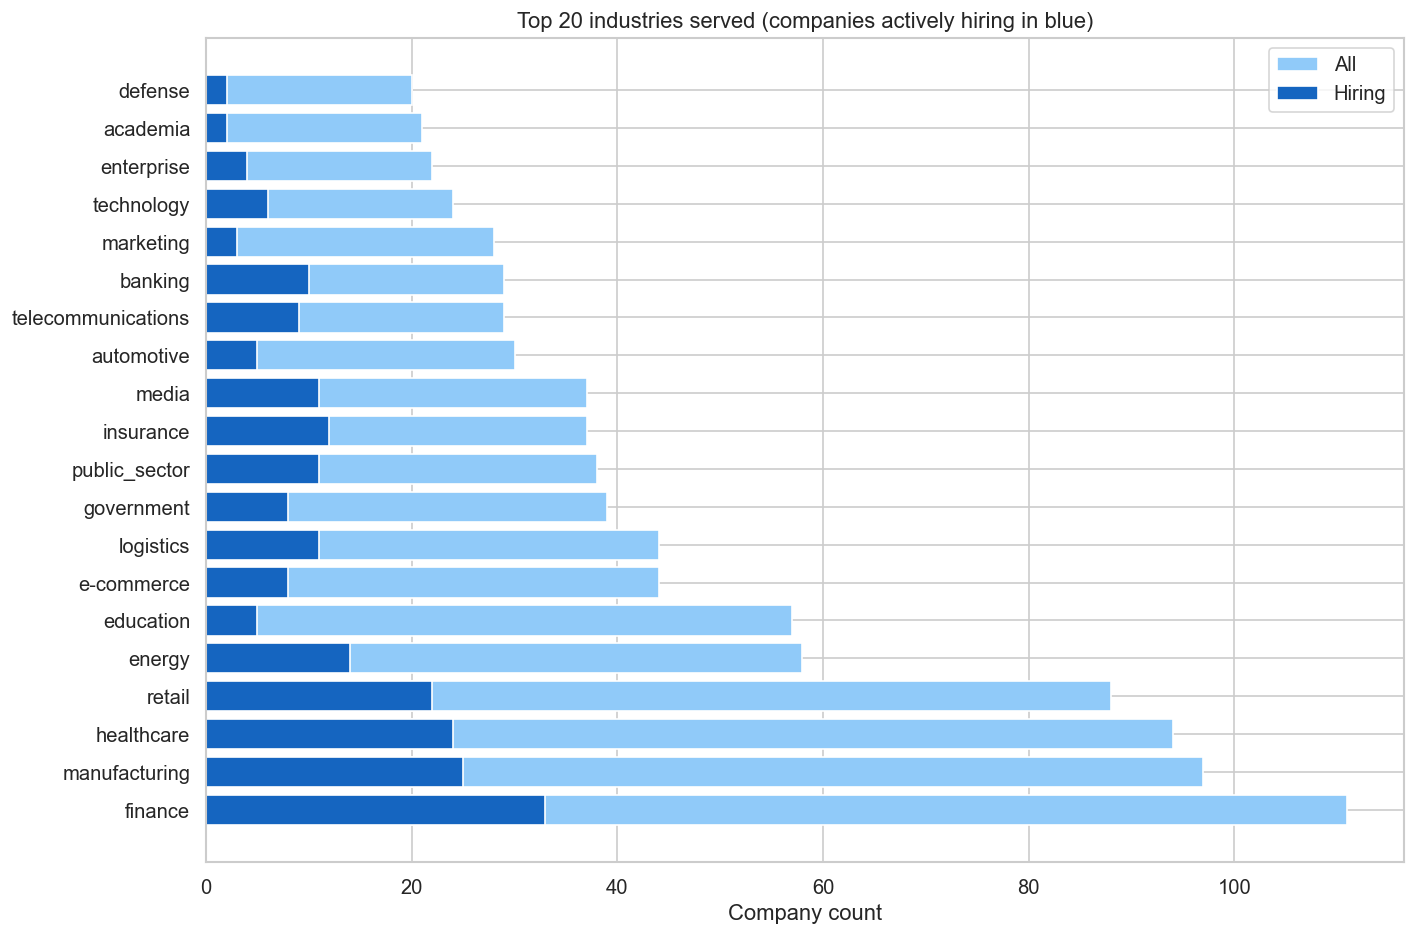

In [8]:
industry_counter = Counter(ind for inds in df["industries_served"] for ind in inds)
top_industries = pd.DataFrame(
    industry_counter.most_common(20), columns=["industry", "count"]
)

# Hiring rate per industry
ind_hiring = Counter(
    ind for _, row in df[df["is_hiring"]].iterrows() for ind in row["industries_served"]
)
top_industries["hiring_count"] = (
    top_industries["industry"].map(ind_hiring).fillna(0).astype(int)
)
top_industries["hiring_pct"] = (
    top_industries["hiring_count"] / top_industries["count"] * 100
).round(1)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(
    top_industries["industry"], top_industries["count"], color="#90CAF9", label="All"
)
ax.barh(
    top_industries["industry"],
    top_industries["hiring_count"],
    color="#1565C0",
    label="Hiring",
)
ax.set_title("Top 20 industries served (companies actively hiring in blue)")
ax.set_xlabel("Company count")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Size distribution

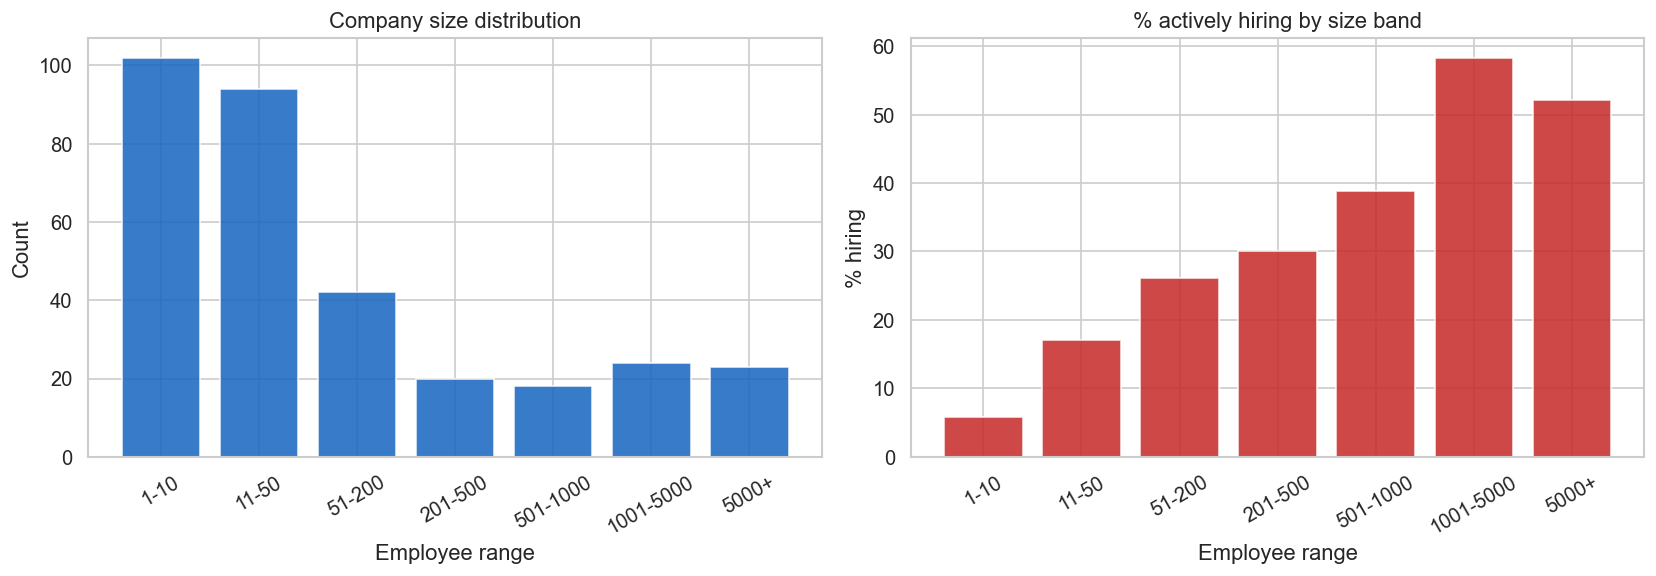

In [9]:
size_counts = (
    companies["employees_range"].value_counts().reindex(EMP_ORDER, fill_value=0)
)

# Hiring rate per size band
size_hiring = (
    companies[companies["is_hiring"]]["employees_range"]
    .value_counts()
    .reindex(EMP_ORDER, fill_value=0)
)
hiring_rate = (size_hiring / size_counts.replace(0, pd.NA) * 100).fillna(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(size_counts.index, size_counts.values, color="#1565C0", alpha=0.85)
ax1.set_title("Company size distribution")
ax1.set_xlabel("Employee range")
ax1.set_ylabel("Count")
ax1.tick_params(axis="x", rotation=30)

ax2.bar(hiring_rate.index, hiring_rate.values, color="#C62828", alpha=0.85)
ax2.set_title("% actively hiring by size band")
ax2.set_xlabel("Employee range")
ax2.set_ylabel("% hiring")
ax2.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 7. Funding landscape

Companies with disclosed funding: 35 / 323
Total disclosed funding: $2260M
Median (funded): $10.0M



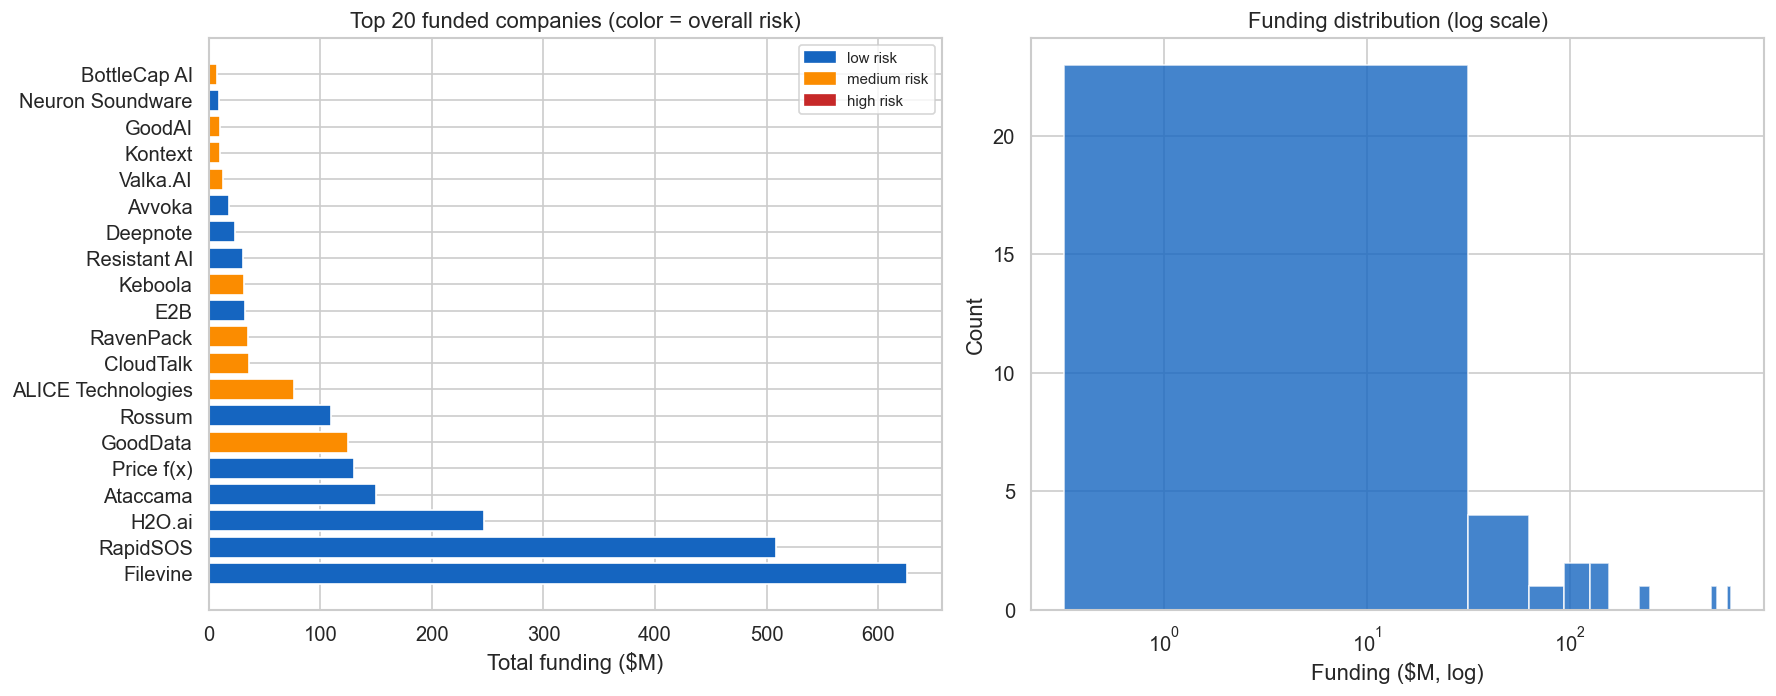


Funding stage breakdown (by n_rounds):
stage_bucket
bootstrapped/undisclosed    265
seed/angel                   34
early (2 rounds)             15
growth (3 rounds)             7
4+ rounds                     2


In [10]:
from matplotlib.patches import Patch

funded_df = companies[companies["funding_M"].notna()].sort_values(
    "funding_M", ascending=False
)

print(f"Companies with disclosed funding: {len(funded_df)} / {len(companies)}")
print(f"Total disclosed funding: ${funded_df['funding_M'].sum():.0f}M")
print(f"Median (funded): ${funded_df['funding_M'].median():.1f}M")
print()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

top20 = funded_df.head(20)
colors = [
    "#C62828" if r == "high" else "#FB8C00" if r == "medium" else "#1565C0"
    for r in top20["overall_risk"]
]
ax1.barh(top20["name"], top20["funding_M"], color=colors)
ax1.set_title("Top 20 funded companies (color = overall risk)")
ax1.set_xlabel("Total funding ($M)")
ax1.legend(
    handles=[
        Patch(color="#1565C0", label="low risk"),
        Patch(color="#FB8C00", label="medium risk"),
        Patch(color="#C62828", label="high risk"),
    ],
    fontsize=9,
)

ax2.hist(funded_df["funding_M"], bins=20, color="#1565C0", alpha=0.8, edgecolor="white")
ax2.set_xscale("log")
ax2.set_title("Funding distribution (log scale)")
ax2.set_xlabel("Funding ($M, log)")
ax2.set_ylabel("Count")

plt.tight_layout()
plt.show()

print("\nFunding stage breakdown (by n_rounds):")
companies["n_rounds"] = companies["funding_rounds"].apply(len)
stage_map = {
    0: "bootstrapped/undisclosed",
    1: "seed/angel",
    2: "early (2 rounds)",
    3: "growth (3 rounds)",
    99: "4+ rounds",
}
companies["stage_bucket"] = companies["n_rounds"].apply(
    lambda n: stage_map.get(n, "4+ rounds")
)
print(companies["stage_bucket"].value_counts().to_string())

## 8. Risk assessment deep-dive

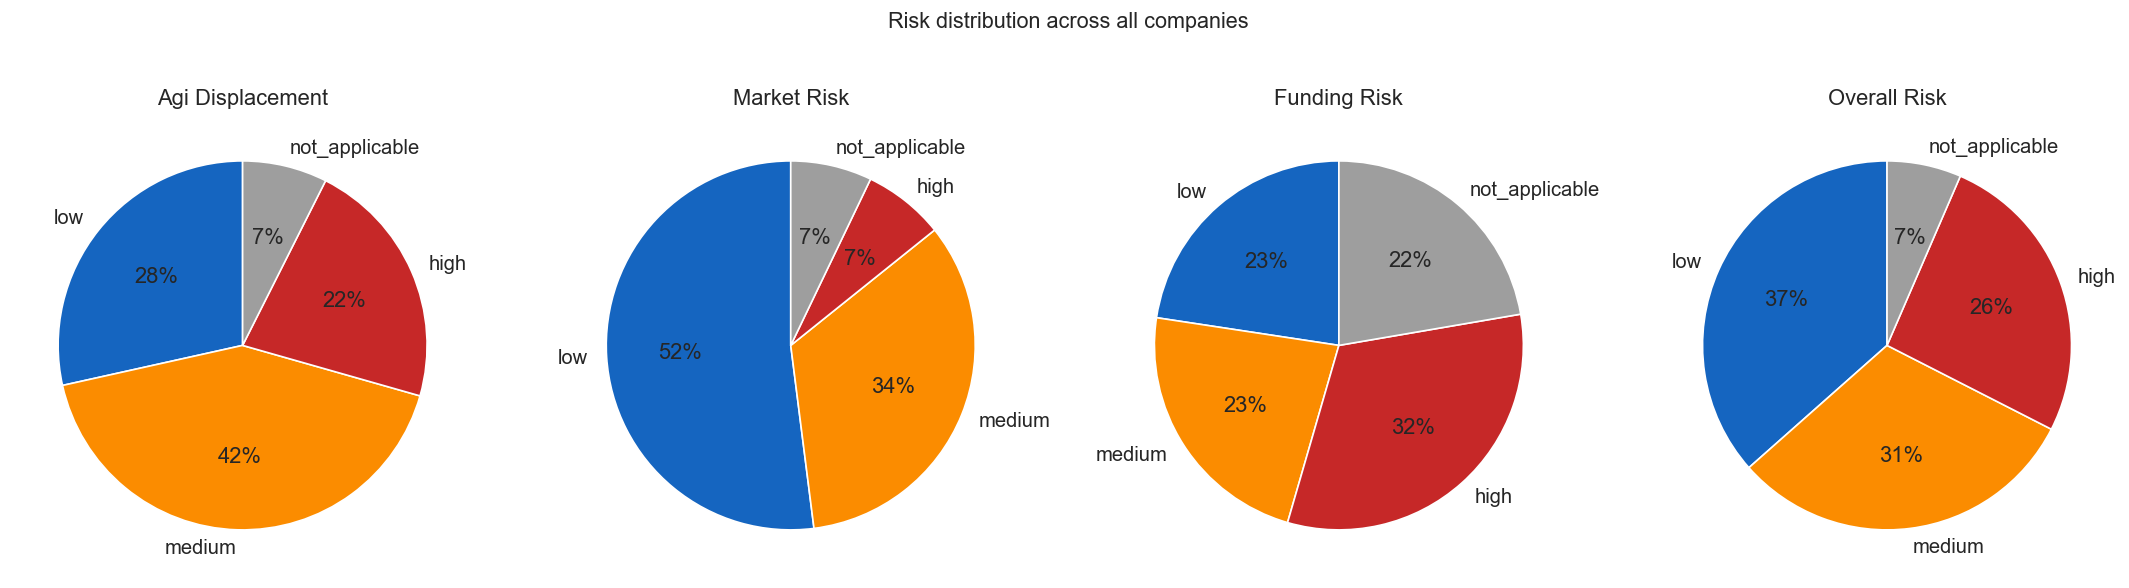

In [11]:
risk_cols = ["agi_displacement", "market_risk", "funding_risk", "overall_risk"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
palette = {
    "low": "#1565C0",
    "medium": "#FB8C00",
    "high": "#C62828",
    "not_applicable": "#9E9E9E",
}

for ax, col in zip(axes, risk_cols):
    vc = (
        companies[col]
        .value_counts()
        .reindex(["low", "medium", "high", "not_applicable"])
        .dropna()
    )
    colors = [palette.get(i, "#ccc") for i in vc.index]
    ax.pie(vc, labels=vc.index, autopct="%1.0f%%", colors=colors, startangle=90)
    ax.set_title(col.replace("_", " ").title())

plt.suptitle("Risk distribution across all companies", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

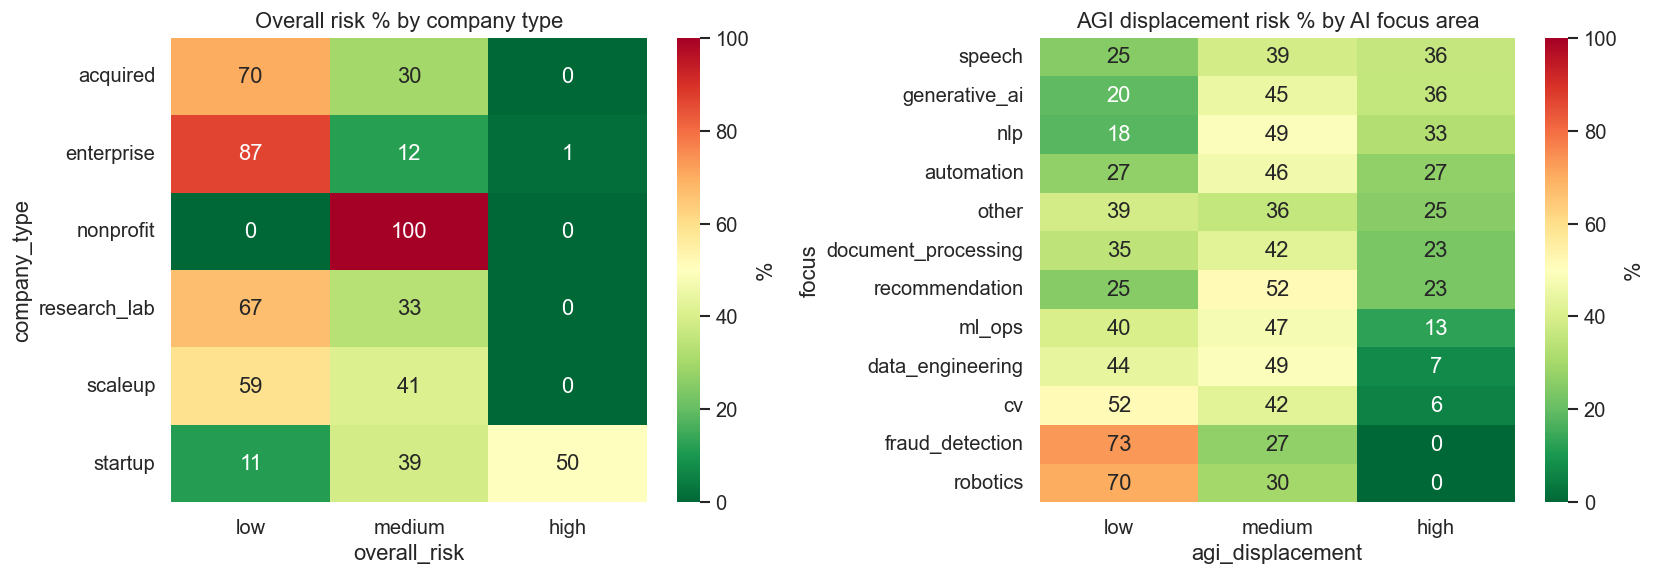

In [12]:
# Risk × company type heatmap
pivot = companies.groupby(["company_type", "overall_risk"]).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=["low", "medium", "high"], fill_value=0)

# Normalize to %
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    pivot_pct,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn_r",
    ax=ax1,
    cbar_kws={"label": "%"},
    vmin=0,
    vmax=100,
)
ax1.set_title("Overall risk % by company type")

# AGI displacement by AI focus
agi_focus_rows = []
for _, row in companies.iterrows():
    for focus in row["ai_focus"]:
        agi_focus_rows.append(
            {"focus": focus, "agi_displacement": row["agi_displacement"]}
        )

agi_df = pd.DataFrame(agi_focus_rows)
agi_pivot = agi_df.groupby(["focus", "agi_displacement"]).size().unstack(fill_value=0)
agi_pivot = agi_pivot.reindex(columns=["low", "medium", "high"], fill_value=0)
agi_pct = agi_pivot.div(agi_pivot.sum(axis=1), axis=0) * 100
agi_pct["high_pct"] = agi_pct.get("high", 0)
agi_pct = agi_pct.sort_values("high_pct", ascending=False).drop(columns="high_pct")

sns.heatmap(
    agi_pct,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn_r",
    ax=ax2,
    cbar_kws={"label": "%"},
    vmin=0,
    vmax=100,
)
ax2.set_title("AGI displacement risk % by AI focus area")

plt.tight_layout()
plt.show()

## 9. Tech stack demand

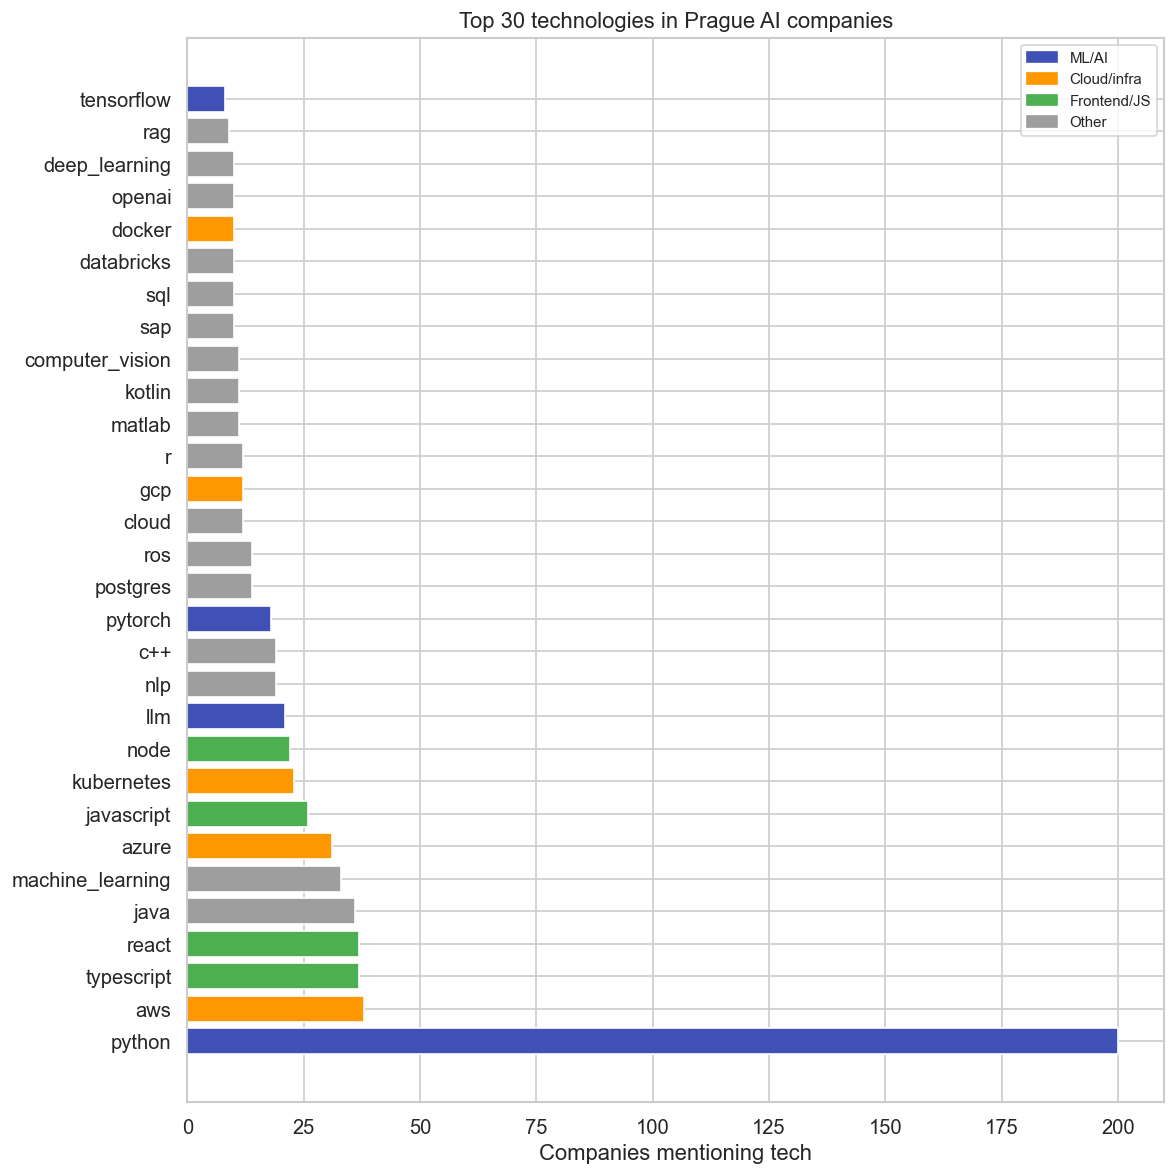

Unique technologies mentioned: 436
Avg tech stack size per company: 3.7


In [13]:
from matplotlib.patches import Patch

ALIASES = {
    "node.js": "node",
    "nodejs": "node",
    "react.js": "react",
    "reactjs": "react",
    "vue.js": "vue",
    "vuejs": "vue",
    "postgresql": "postgres",
    "postgressql": "postgres",
    "tensorflow": "tensorflow",
    "tf": "tensorflow",
    "pytorch": "pytorch",
    "torch": "pytorch",
    "kubernetes": "kubernetes",
    "k8s": "kubernetes",
    "javascript": "javascript",
    "js": "javascript",
    "typescript": "typescript",
    "ts": "typescript",
    "amazon web services": "aws",
    "amazon aws": "aws",
    "google cloud": "gcp",
    "google cloud platform": "gcp",
    "microsoft azure": "azure",
    "large language models": "llm",
    "llms": "llm",
    "machine learning": "ml",
    "deep learning": "deep learning",
}


def normalize_tech(t):
    t = t.lower().strip()
    return ALIASES.get(t, t)


tech_counter = Counter(normalize_tech(t) for row in df["tech_stack"] for t in row if t)

top_tech = pd.DataFrame(tech_counter.most_common(30), columns=["tech", "count"])

fig, ax = plt.subplots(figsize=(10, 10))
tech_categories = {
    "python": "#3F51B5",
    "pytorch": "#3F51B5",
    "tensorflow": "#3F51B5",
    "ml": "#3F51B5",
    "deep learning": "#3F51B5",
    "llm": "#3F51B5",
    "aws": "#FF9800",
    "gcp": "#FF9800",
    "azure": "#FF9800",
    "kubernetes": "#FF9800",
    "docker": "#FF9800",
    "react": "#4CAF50",
    "javascript": "#4CAF50",
    "typescript": "#4CAF50",
    "node": "#4CAF50",
    "vue": "#4CAF50",
}
bar_colors = [tech_categories.get(t, "#9E9E9E") for t in top_tech["tech"]]
ax.barh(top_tech["tech"], top_tech["count"], color=bar_colors)
ax.set_title("Top 30 technologies in Prague AI companies")
ax.set_xlabel("Companies mentioning tech")
ax.legend(
    handles=[
        Patch(color="#3F51B5", label="ML/AI"),
        Patch(color="#FF9800", label="Cloud/infra"),
        Patch(color="#4CAF50", label="Frontend/JS"),
        Patch(color="#9E9E9E", label="Other"),
    ],
    fontsize=9,
)
plt.tight_layout()
plt.show()

print(f"Unique technologies mentioned: {len(tech_counter)}")
print(f"Avg tech stack size per company: {df['tech_stack'].apply(len).mean():.1f}")

## 10. Open roles analysis

Total open roles tracked: 592
Companies with open roles: 152



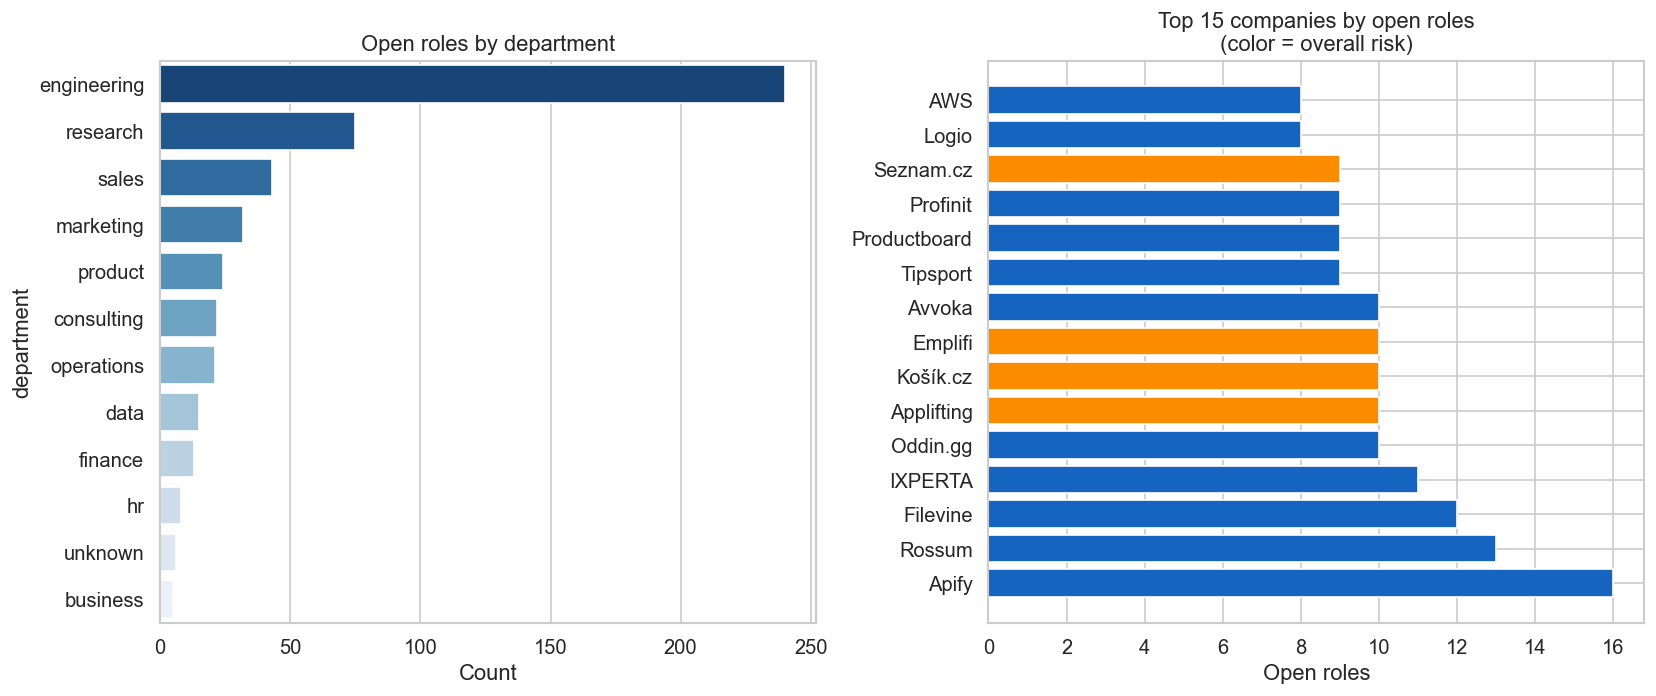


AI/ML-specific roles: 136 / 592 (23%)

Top AI/ML role titles:
title
Machine Learning Engineer                   5
AI Engineer                                 4
Postdoctoral Researcher                     3
Senior AI Engineer                          2
AI/ML Engineer                              2
Data Engineer                               2
Data Scientist                              2
PhD Student (Machine Learning)              1
Postdoctoral Fellow (Machine Learning)      1
Postdoc Researcher                          1
AI / LLM Engineer                           1
Market Analyst / AI QA Operator             1
AI Tamer (general application)              1
PhD Student / Researcher (We Are Hiring)    1
Senior Data Scientist                       1


In [14]:
role_rows = []
for _, row in df.iterrows():
    for role in row["open_roles"]:
        if isinstance(role, dict):
            title = role.get("title", "")
            dept = role.get("department", "unknown")
            loc = role.get("location", "")
        else:
            title = str(role)
            dept = "unknown"
            loc = ""
        role_rows.append(
            {
                "company": row["name"],
                "company_id": row["id"],
                "title": title,
                "department": dept,
                "location": loc,
                "overall_risk": row["overall_risk"],
                "company_type": row["company_type"],
                "funding_M": row["funding_M"],
            }
        )

roles_df = pd.DataFrame(role_rows)
print(f"Total open roles tracked: {len(roles_df)}")
print(f"Companies with open roles: {roles_df['company_id'].nunique()}")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Department breakdown
dept_counts = roles_df["department"].value_counts().head(12)
sns.barplot(x=dept_counts.values, y=dept_counts.index, ax=axes[0], palette="Blues_r")
axes[0].set_title("Open roles by department")
axes[0].set_xlabel("Count")

# Roles per company (top 15)
top_hirers = roles_df.groupby("company").size().sort_values(ascending=False).head(15)
risk_map = df.set_index("name")["overall_risk"].to_dict()
bar_colors = [
    {"low": "#1565C0", "medium": "#FB8C00", "high": "#C62828"}.get(
        risk_map.get(c, ""), "#9E9E9E"
    )
    for c in top_hirers.index
]
axes[1].barh(top_hirers.index, top_hirers.values, color=bar_colors)
axes[1].set_title("Top 15 companies by open roles\n(color = overall risk)")
axes[1].set_xlabel("Open roles")

plt.tight_layout()
plt.show()

# AI/ML specific roles
ai_keywords = [
    "data scientist",
    "ml ",
    "machine learning",
    "ai ",
    "nlp",
    "computer vision",
    "deep learning",
    "llm",
    "research",
    "data engineer",
    "mlops",
    "analytics",
]
roles_df["is_ai_role"] = (
    roles_df["title"].str.lower().apply(lambda t: any(k in t for k in ai_keywords))
)
print(
    f"\nAI/ML-specific roles: {roles_df['is_ai_role'].sum()} / {len(roles_df)} ({100 * roles_df['is_ai_role'].mean():.0f}%)"
)
print("\nTop AI/ML role titles:")
print(roles_df[roles_df["is_ai_role"]]["title"].value_counts().head(15).to_string())

## 11. Research-to-commercial gap

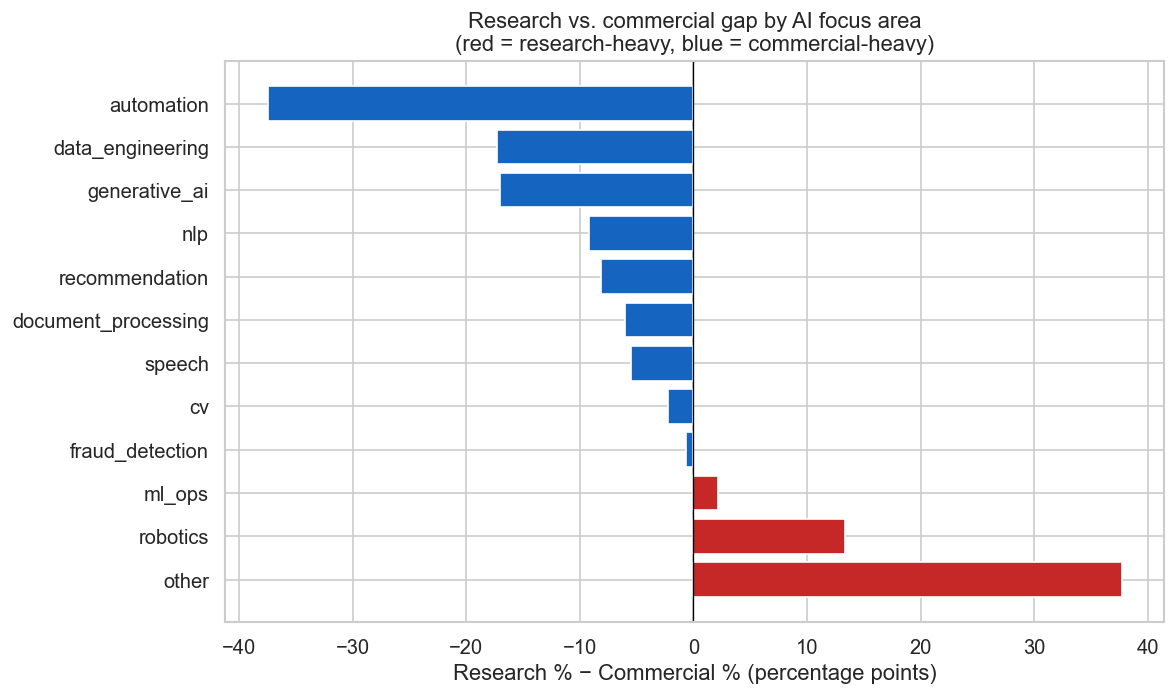

              focus  research  commercial  research_pct  commercial_pct        gap
              other        30          72          60.0       22.291022  37.708978
           robotics         9          15          18.0        4.643963  13.356037
             ml_ops        24         148          48.0       45.820433   2.179567
    fraud_detection         2          15           4.0        4.643963  -0.643963
                 cv         8          59          16.0       18.266254  -2.266254
             speech         3          37           6.0       11.455108  -5.455108
document_processing         1          26           2.0        8.049536  -6.049536
     recommendation         4          52           8.0       16.099071  -8.099071
                nlp        14         120          28.0       37.151703  -9.151703
      generative_ai        11         126          22.0       39.009288 -17.009288
   data_engineering         7         101          14.0       31.269350 -17.269350
    

In [15]:
research = df[df["category"] != "company"]
commercial = df[df["category"] == "company"]

research_focus = Counter(tag for tags in research["ai_focus"] for tag in tags)
commercial_focus = Counter(tag for tags in commercial["ai_focus"] for tag in tags)

all_tags = sorted(set(research_focus) | set(commercial_focus))
gap_df = pd.DataFrame(
    {
        "focus": all_tags,
        "research": [research_focus.get(t, 0) for t in all_tags],
        "commercial": [commercial_focus.get(t, 0) for t in all_tags],
    }
)

total_r = len(research) or 1
total_c = len(commercial) or 1
gap_df["research_pct"] = gap_df["research"] / total_r * 100
gap_df["commercial_pct"] = gap_df["commercial"] / total_c * 100
gap_df["gap"] = (
    gap_df["research_pct"] - gap_df["commercial_pct"]
)  # positive = research-heavy
gap_df = gap_df.sort_values("gap", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#C62828" if g > 0 else "#1565C0" for g in gap_df["gap"]]
ax.barh(gap_df["focus"], gap_df["gap"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(
    "Research vs. commercial gap by AI focus area\n(red = research-heavy, blue = commercial-heavy)"
)
ax.set_xlabel("Research % − Commercial % (percentage points)")
plt.tight_layout()
plt.show()

print(
    gap_df[
        ["focus", "research", "commercial", "research_pct", "commercial_pct", "gap"]
    ].to_string(index=False)
)

## 12. Job-seeker target list: low risk × actively hiring

## 12b. Full company ranking: risk + hiring + coolness

In [16]:
# --- Coolness score ---
FOCUS_COOL = {
    "generative_ai": 10,
    "robotics": 9,
    "cv": 8,
    "nlp": 7,
    "speech": 7,
    "recommendation": 5,
    "ml_ops": 4,
    "automation": 3,
    "data_engineering": 2,
    "other": 3,
}
INDUSTRY_COOL = {
    "healthcare": 9,
    "robotics": 9,
    "space": 9,
    "biotech": 8,
    "autonomous_vehicles": 8,
    "defense": 7,
    "legal": 6,
    "finance": 6,
    "cybersecurity": 6,
    "education": 5,
    "ecommerce": 4,
    "hr": 3,
    "consulting": 2,
    "developer_tools": 7,
    "marketing": 3,
}


def coolness_score(row):
    focus_scores = [FOCUS_COOL.get(f, 3) for f in row["ai_focus"]]
    focus_cool = max(focus_scores) if focus_scores else 0
    ind_scores = [INDUSTRY_COOL.get(i, 4) for i in row["industries_served"]]
    ind_cool = max(ind_scores) if ind_scores else 0
    year = row["founded_year"] or 0
    recency = 4 if year >= 2021 else (2 if year >= 2018 else 0)
    native = 3 if row["is_ai_native"] else 0
    credibility = min(len(row["awards"]) + len(row["notable_clients"]), 4)
    return round(
        focus_cool * 0.40
        + ind_cool * 0.25
        + recency * 0.15
        + native * 0.10
        + credibility * 0.10,
        2,
    )


RISK_SCORE = {"low": 10, "medium": 5, "high": 1, "not_applicable": 7}


def risk_score(row):
    overall = RISK_SCORE.get(row["overall_risk"], 5)
    agi = RISK_SCORE.get(row["agi_displacement"], 5)
    market = RISK_SCORE.get(row["market_risk"], 5)
    funding = RISK_SCORE.get(row["funding_risk"], 7)
    return overall * 0.40 + agi * 0.25 + market * 0.20 + funding * 0.15


HIRING_SCORE = {"actively_hiring": 10, "few_roles": 4, "not_hiring": 0, "unknown": 2}


def hiring_score(row):
    base = HIRING_SCORE.get(row["hiring_signals"], 2)
    roles_bonus = min(row["n_open_roles"], 10)
    return base * 0.7 + roles_bonus * 0.3


ranked = companies.copy()
ranked["cool_score"] = ranked.apply(coolness_score, axis=1)
ranked["risk_score"] = ranked.apply(risk_score, axis=1)
ranked["hiring_score"] = ranked.apply(hiring_score, axis=1)
ranked["composite"] = (
    ranked["cool_score"] * 0.35
    + ranked["risk_score"] * 0.40
    + ranked["hiring_score"] * 0.25
).round(2)

ranked = ranked.sort_values("composite", ascending=False).reset_index(drop=True)
ranked.index += 1

pd.set_option("display.max_rows", 300)
pd.set_option("display.width", 160)
print(
    f"{'Rank':<5} {'Company':<40} {'Type':<12} {'Risk':<8} {'Hiring':<20} {'Cool':>5} {'Risk_s':>6} {'Hire_s':>6} {'Score':>6}"
)
print("-" * 115)
for rank, row in ranked.iterrows():
    print(
        f"{rank:<5} {row['name'][:39]:<40} {str(row['company_type'])[:11]:<12} "
        f"{str(row['overall_risk']):<8} {str(row['hiring_signals'])[:19]:<20} "
        f"{row['cool_score']:>5.1f} {row['risk_score']:>6.1f} {row['hiring_score']:>6.1f} {row['composite']:>6.2f}"
    )

Rank  Company                                  Type         Risk     Hiring                Cool Risk_s Hire_s  Score
-------------------------------------------------------------------------------------------------------------------
1     Amazon                                   enterprise   low      actively_hiring        6.7    9.6    8.8   8.35
2     IBM                                      enterprise   low      actively_hiring        6.7    9.6    8.5   8.27
3     Born Digital                             startup      low      actively_hiring        7.0    9.2    8.5   8.26
4     Carebot                                  startup      low      actively_hiring        6.8    9.2    8.5   8.19
5     SAP                                      enterprise   low      actively_hiring        6.7    8.8    9.4   8.18
6     Bindworks                                startup      low      actively_hiring        7.0    9.2    8.2   8.18
7     Filevine                                 scaleup      low  

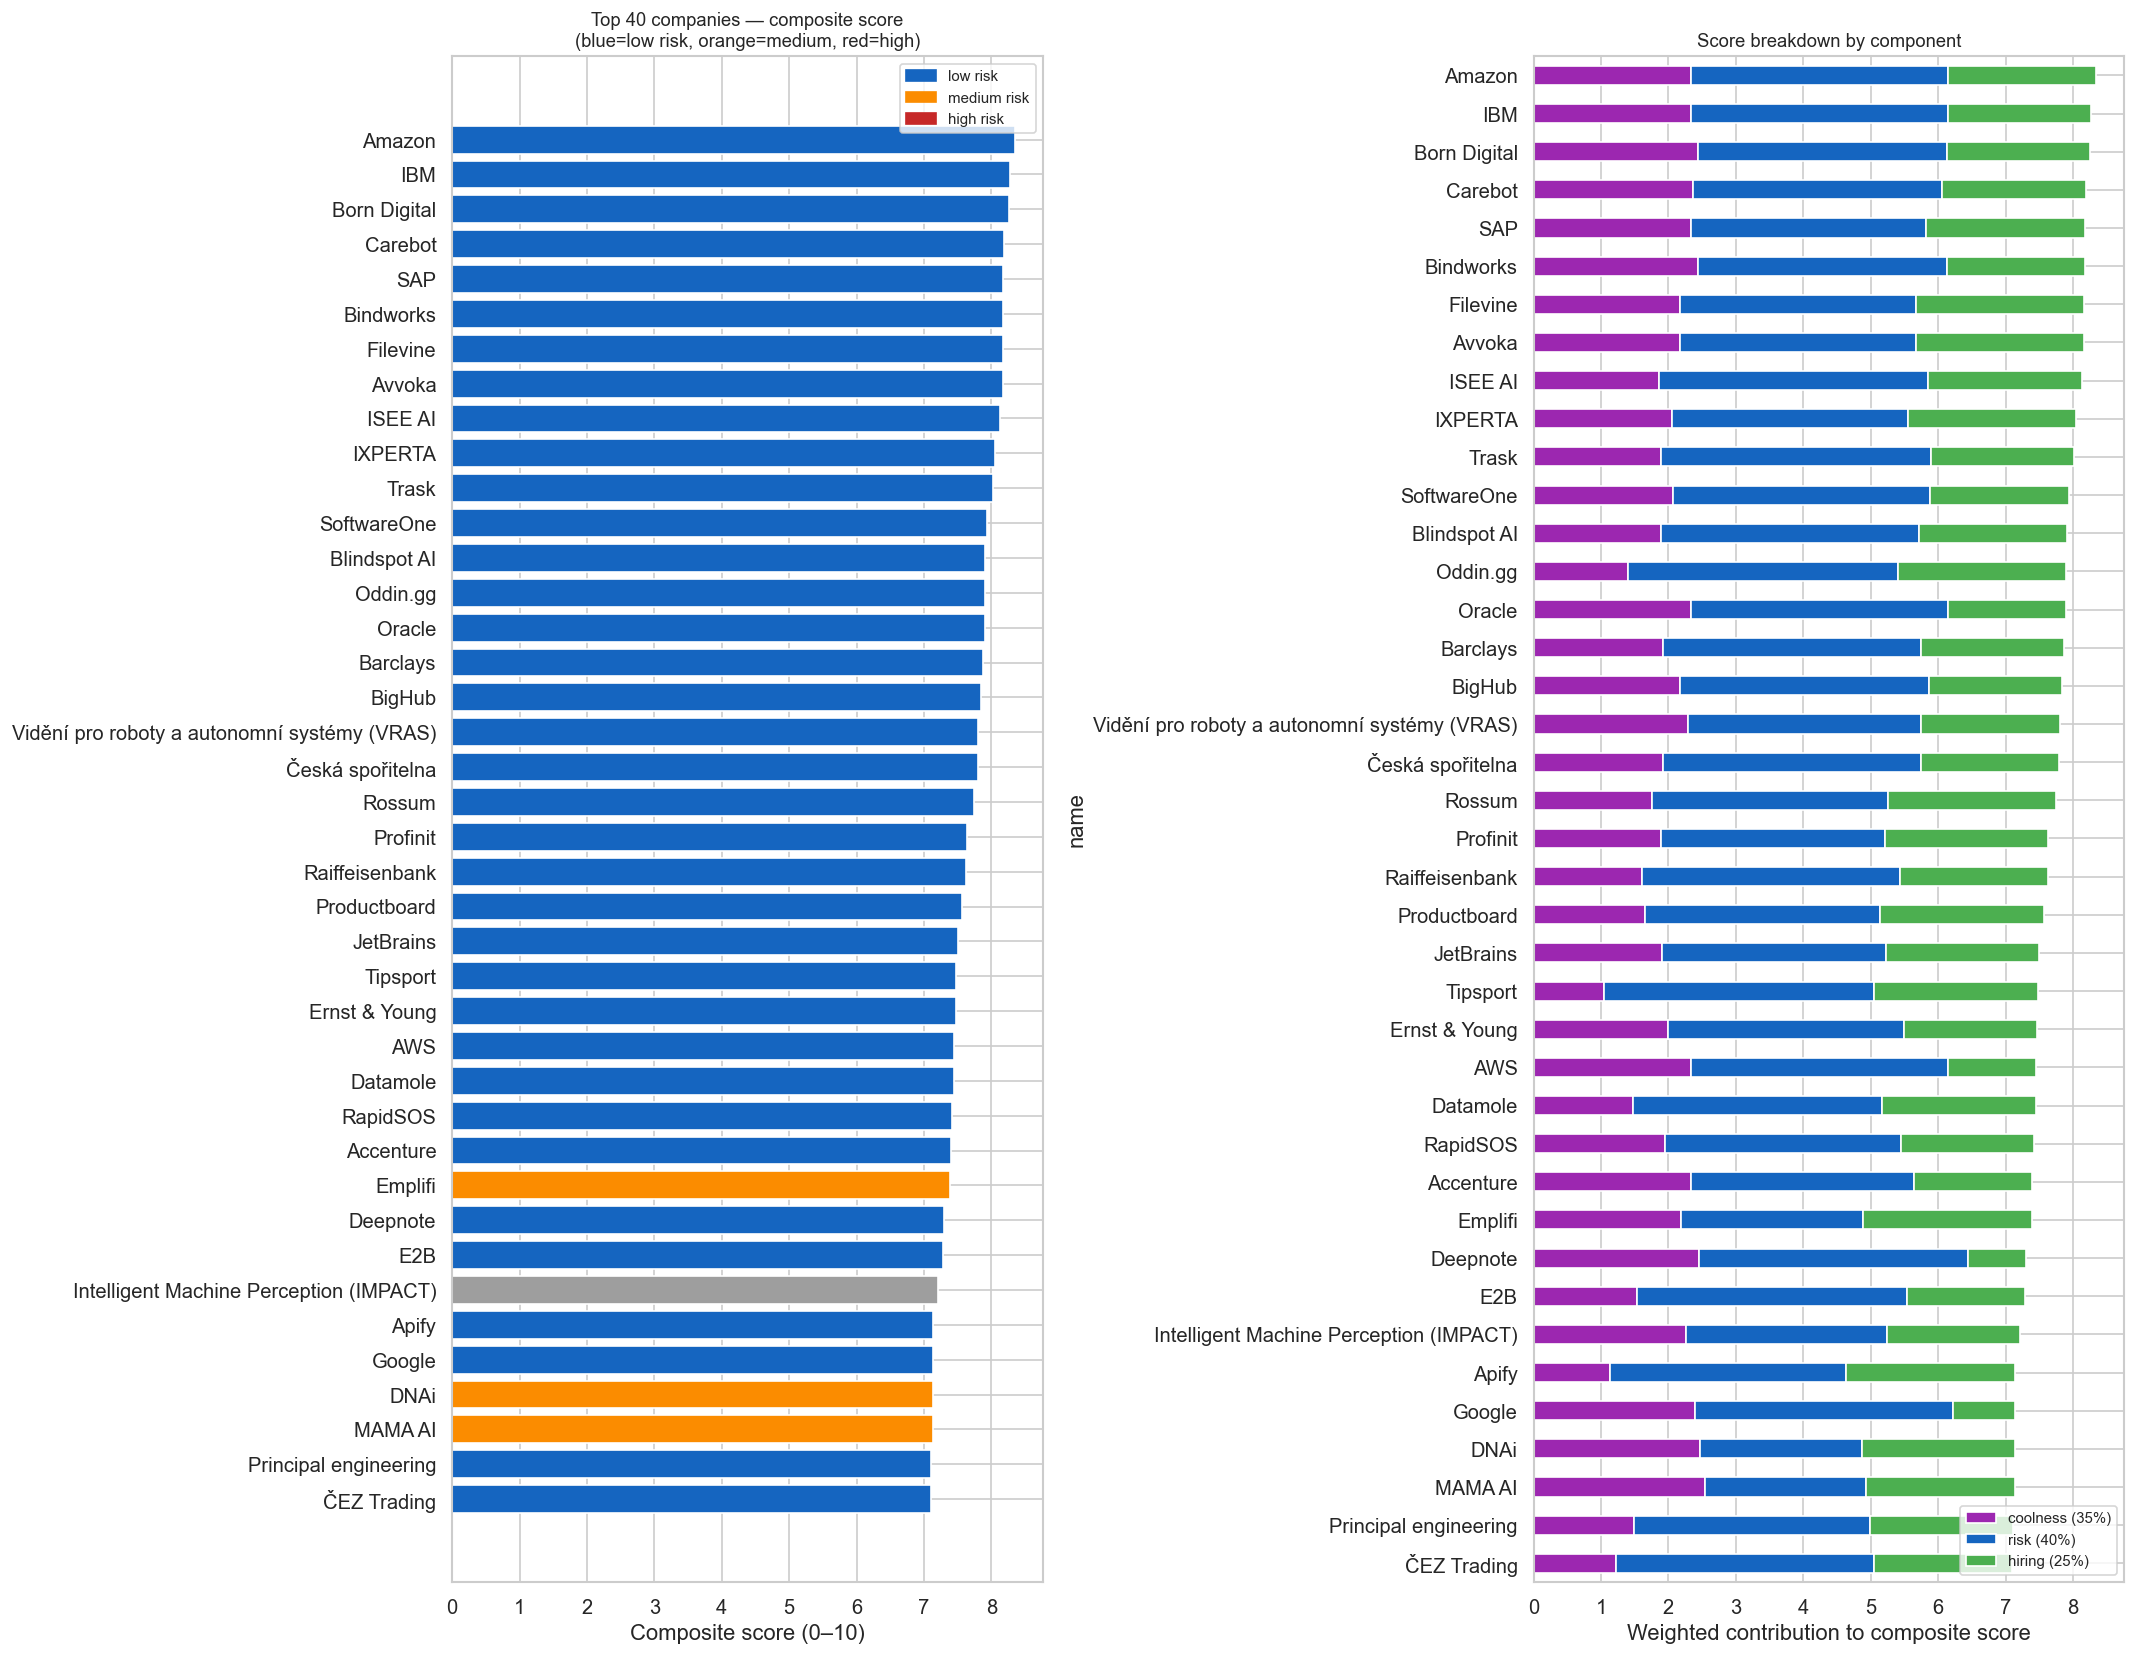

In [17]:
from matplotlib.patches import Patch

top40 = ranked.head(40)

fig, axes = plt.subplots(1, 2, figsize=(18, 14))

risk_colors = {"low": "#1565C0", "medium": "#FB8C00", "high": "#C62828"}
colors = [risk_colors.get(r, "#9E9E9E") for r in top40["overall_risk"]]
axes[0].barh(top40["name"][::-1], top40["composite"][::-1], color=colors[::-1])
axes[0].set_title(
    "Top 40 companies — composite score\n(blue=low risk, orange=medium, red=high)",
    fontsize=11,
)
axes[0].set_xlabel("Composite score (0–10)")
axes[0].legend(
    handles=[
        Patch(color="#1565C0", label="low risk"),
        Patch(color="#FB8C00", label="medium risk"),
        Patch(color="#C62828", label="high risk"),
    ],
    fontsize=9,
)

comp_data = (
    top40[["name", "cool_score", "risk_score", "hiring_score"]]
    .set_index("name")
    .iloc[::-1]
)
comp_weighted = pd.DataFrame(
    {
        "coolness (35%)": comp_data["cool_score"] * 0.35,
        "risk (40%)": comp_data["risk_score"] * 0.40,
        "hiring (25%)": comp_data["hiring_score"] * 0.25,
    }
)
comp_weighted.plot(
    kind="barh", stacked=True, ax=axes[1], color=["#9C27B0", "#1565C0", "#4CAF50"]
)
axes[1].set_title("Score breakdown by component", fontsize=11)
axes[1].set_xlabel("Weighted contribution to composite score")
axes[1].legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

In [18]:
targets = companies[
    (companies["overall_risk"] == "low") & companies["is_hiring"]
].copy()

targets["score"] = (
    targets["n_open_roles"] * 2
    + targets["is_funded"].astype(int) * 3
    + targets["is_ai_native"].astype(int) * 2
    + (targets["company_type"] == "scaleup").astype(int) * 2
)

targets = targets.sort_values("score", ascending=False)

print(f"Low-risk + actively hiring companies: {len(targets)}\n")
display_cols = [
    "name",
    "company_type",
    "employees_range",
    "n_open_roles",
    "is_funded",
    "is_ai_native",
    "business_model",
    "score",
]
print(targets[display_cols].to_string(index=False))

Low-risk + actively hiring companies: 44

                                        name company_type employees_range  n_open_roles  is_funded  is_ai_native      business_model  score
                                       Apify      scaleup          51-200            16       True         False         usage_based     37
                                      Rossum      scaleup         201-500            13       True          True   subscription_saas     33
                                    Filevine      scaleup        501-1000            12       True          True   subscription_saas     31
                                    Oddin.gg      scaleup         201-500            10       True          True   subscription_saas     27
                                      Avvoka      startup          51-200            10       True          True   subscription_saas     25
                                Productboard      scaleup        501-1000             9       True         False   sub

## 13. Business model distribution

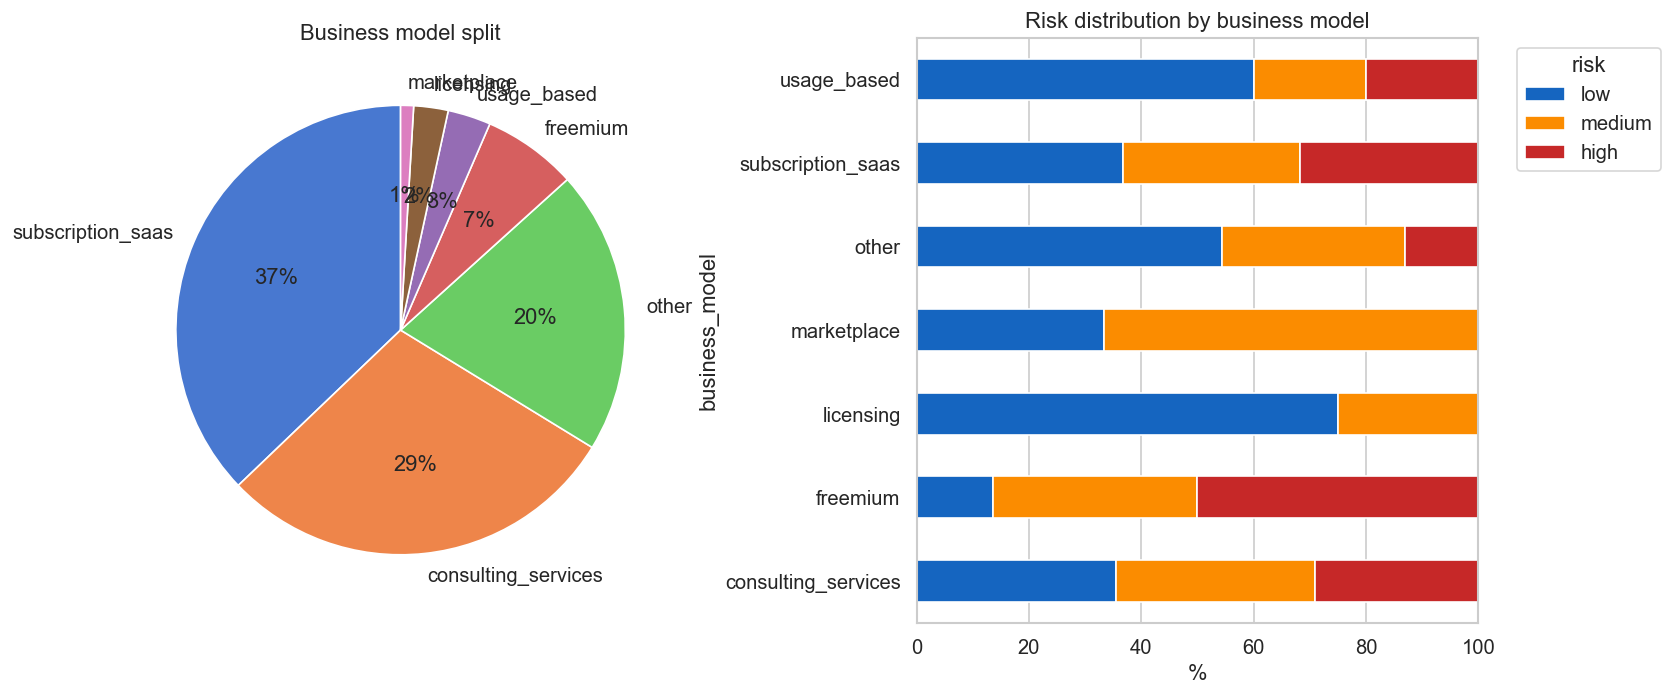

In [19]:
bm = companies["business_model"].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.pie(bm, labels=bm.index, autopct="%1.0f%%", startangle=90)
ax1.set_title("Business model split")

# Risk by business model
bm_risk = (
    companies.groupby(["business_model", "overall_risk"]).size().unstack(fill_value=0)
)
bm_risk = bm_risk.reindex(columns=["low", "medium", "high"], fill_value=0)
bm_risk_pct = bm_risk.div(bm_risk.sum(axis=1), axis=0) * 100
bm_risk_pct.plot(
    kind="barh", stacked=True, ax=ax2, color=["#1565C0", "#FB8C00", "#C62828"]
)
ax2.set_title("Risk distribution by business model")
ax2.set_xlabel("%")
ax2.legend(title="risk", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

## 14. Summary: key numbers

In [20]:
hiring_df = companies[companies["is_hiring"]]
low_risk_hiring = companies[
    (companies["overall_risk"] == "low") & companies["is_hiring"]
]
funded_hiring = companies[companies["is_funded"] & companies["is_hiring"]]

print("=" * 55)
print("PRAGUE AI CATALOG — SUMMARY STATS")
print("=" * 55)
print(f"  Total entities:           {len(df)}")
print(f"  Commercial companies:     {len(companies)}")
print(f"  Research groups:          {len(df[df['category'] != 'company'])}")
print()
print(
    f"  AI-native companies:      {companies['is_ai_native'].sum()} ({100 * companies['is_ai_native'].mean():.0f}%)"
)
print(
    f"  Actively hiring:          {hiring_df.shape[0]} ({100 * hiring_df.shape[0] / len(companies):.0f}%)"
)
print(
    f"  Funded (disclosed):       {companies['is_funded'].sum()} ({100 * companies['is_funded'].mean():.0f}%)"
)
print(f"  Total disclosed funding:  ${funded_df['funding_M'].sum():.0f}M")
print()
print(
    f"  Low overall risk:         {(companies['overall_risk'] == 'low').sum()} ({100 * (companies['overall_risk'] == 'low').mean():.0f}%)"
)
print(f"  Low risk + hiring:        {len(low_risk_hiring)}")
print(f"  Funded + hiring:          {len(funded_hiring)}")
print()
print(f"  Total open roles tracked: {len(roles_df)}")
print(f"  AI/ML-specific roles:     {roles_df['is_ai_role'].sum()}")
print(f"  Unique technologies:      {len(tech_counter)}")
print(
    f"  Top AI focus:             {focus_df.iloc[0]['focus']} ({focus_df.iloc[0]['count']} companies)"
)
print(
    f"  Top industry:             {top_industries.iloc[0]['industry']} ({top_industries.iloc[0]['count']} companies)"
)
print("=" * 55)

PRAGUE AI CATALOG — SUMMARY STATS
  Total entities:           373
  Commercial companies:     323
  Research groups:          50

  AI-native companies:      179 (55%)
  Actively hiring:          72 (22%)
  Funded (disclosed):       59 (18%)
  Total disclosed funding:  $2260M

  Low overall risk:         118 (37%)
  Low risk + hiring:        44
  Funded + hiring:          22

  Total open roles tracked: 592
  AI/ML-specific roles:     136
  Unique technologies:      436
  Top AI focus:             automation (233 companies)
  Top industry:             finance (111 companies)
